# MLP Baseline for Skeleton Action Recognition



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 1: Imports
import os
import math
import pickle
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt


In [3]:
# Cell 2: Seed and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch version:", torch.__version__)


device: cuda
torch version: 2.10.0+cu128


In [4]:
# Cell 3: Path to your pkl file
PKL_PATH = "/content/drive/MyDrive/ntu60_hrnet.pkl"

with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys())
print("split keys:", data["split"].keys())
print("num annotations:", len(data["annotations"]))

sample = data["annotations"][0]
print("sample keys:", sample.keys())
print("sample frame_dir:", sample["frame_dir"])
print("sample label:", sample["label"])
print("sample keypoint shape:", sample["keypoint"].shape)
if "keypoint_score" in sample:
    print("sample keypoint_score shape:", sample["keypoint_score"].shape)


<class 'dict'>
dict_keys(['split', 'annotations'])
split keys: dict_keys(['xsub_train', 'xsub_val', 'xview_train', 'xview_val'])
num annotations: 56578
sample keys: dict_keys(['frame_dir', 'label', 'img_shape', 'original_shape', 'total_frames', 'keypoint', 'keypoint_score'])
sample frame_dir: S001C001P001R001A001
sample label: 0
sample keypoint shape: (1, 103, 17, 2)
sample keypoint_score shape: (1, 103, 17)


In [5]:
# Cell 4: Build index from split names to annotation indices
annotations = data["annotations"]
split = data["split"]

frame_dir_to_idx = {}
for i, ann in enumerate(annotations):
    frame_dir_to_idx[ann["frame_dir"]] = i

def build_indices(name_list):
    indices = []
    missing = []
    for name in name_list:
        if name in frame_dir_to_idx:
            indices.append(frame_dir_to_idx[name])
        else:
            missing.append(name)
    return indices, missing

train_indices, missing_train = build_indices(split["xsub_train"])
val_indices, missing_val = build_indices(split["xsub_val"])

print("train size:", len(train_indices))
print("val size:", len(val_indices))
print("missing train names:", len(missing_train))
print("missing val names:", len(missing_val))


train size: 40091
val size: 16487
missing train names: 0
missing val names: 0


In [6]:
# Cell 5: Hyperparameters
NUM_CLASSES = 60
MAX_FRAMES = 100
BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

In [7]:
# Cell 6: Utility functions for preprocessing
def resize_time_axis(seq, target_len=100):
    """
    seq: numpy array shape (C, T, V)
    output: (C, target_len, V)
    """
    C, T, V = seq.shape
    if T == target_len:
        return seq.astype(np.float32)

    old_idx = np.linspace(0, T - 1, num=T)
    new_idx = np.linspace(0, T - 1, num=target_len)

    out = np.zeros((C, target_len, V), dtype=np.float32)
    for c in range(C):

        for v in range(V):
            out[c, :, v] = np.interp(new_idx, old_idx, seq[c, :, v])
    return out


In [8]:
# Cell 7: Dataset
class NTUSkeletonMLPDataset(Dataset):
    def __init__(self, annotations, indices, max_frames=100):
        self.annotations = annotations
        self.indices = indices
        self.max_frames = max_frames

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        ann = self.annotations[self.indices[idx]]

        keypoint = ann["keypoint"]
        score = ann["keypoint_score"]      # expected: (M, T, V)
        label = int(ann["label"])

        M, T, V, C = keypoint.shape
        num_person = 2

        persons = []
        for i in range(num_person):
            if i < M:
                kp = keypoint[i]          # (T, V, C)
                sc = score[i]             # (T, V)
                kp = kp * sc[..., np.newaxis]
            else:
                kp = np.zeros((T, V, C), dtype=np.float32)

            kp = np.transpose(kp, (2, 0, 1))
            kp = resize_time_axis(kp, self.max_frames)

            persons.append(kp)

        kp = np.stack(persons, axis=0)
        mean = kp.mean()
        std = kp.std() + 1e-6
        kp = (kp - mean) / std

        x = kp.reshape(-1).astype(np.float32)   # flatten for MLP
        y = np.int64(label)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)
train_dataset = NTUSkeletonMLPDataset(annotations, train_indices, max_frames=MAX_FRAMES)
val_dataset = NTUSkeletonMLPDataset(annotations, val_indices, max_frames=MAX_FRAMES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

x0, y0 = next(iter(train_loader))
print("batch x shape:", x0.shape)
print("batch y shape:", y0.shape)
print("expected =", 2 * 2 * MAX_FRAMES * 17)

INPUT_DIM = x0.shape[1]
print("input dim:", INPUT_DIM)


batch x shape: torch.Size([64, 6800])
batch y shape: torch.Size([64])
expected = 6800
input dim: 6800


In [9]:
# Cell 8: MLP model
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = MLPClassifier(INPUT_DIM, NUM_CLASSES).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable params:", num_params)



trainable params: 3630396


In [10]:
# Cell 9: Training and evaluation functions
def compute_accuracy(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += compute_accuracy(logits, y) * bs
        total_count += bs

    return total_loss / total_count, total_acc / total_count

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += compute_accuracy(logits, y) * bs
        total_count += bs

    return total_loss / total_count, total_acc / total_count


In [11]:
# Cell 10: Train
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

best_val_acc = 0.0
SAVE_DIR = "/content/drive/MyDrive/skeleton_project_outputs/mlp"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(SAVE_DIR, "best_mlp_baseline.pth")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("best val acc:", best_val_acc)
print("best model saved to:", best_model_path)

history_path = os.path.join(SAVE_DIR, "training_history_mlp.csv")
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(history_path, index=False)
except ImportError:
    import csv
    with open(history_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["train_loss", "train_acc", "val_loss", "val_acc"])
        writer.writerows(zip(
            history["train_loss"],
            history["train_acc"],
            history["val_loss"],
            history["val_acc"],
        ))
print("history saved to:", history_path)


Epoch 01/20 | train_loss=2.8670 train_acc=0.2018 | val_loss=2.5757 val_acc=0.2531
Epoch 02/20 | train_loss=2.2637 train_acc=0.3183 | val_loss=2.2814 val_acc=0.3273
Epoch 03/20 | train_loss=2.0534 train_acc=0.3641 | val_loss=2.1355 val_acc=0.3492
Epoch 04/20 | train_loss=1.9385 train_acc=0.3938 | val_loss=1.9314 val_acc=0.4001
Epoch 05/20 | train_loss=1.8519 train_acc=0.4157 | val_loss=1.9504 val_acc=0.4024
Epoch 06/20 | train_loss=1.8122 train_acc=0.4261 | val_loss=2.3781 val_acc=0.3495
Epoch 07/20 | train_loss=1.7528 train_acc=0.4418 | val_loss=2.3593 val_acc=0.3221
Epoch 08/20 | train_loss=1.7247 train_acc=0.4475 | val_loss=2.3975 val_acc=0.3395
Epoch 09/20 | train_loss=1.6924 train_acc=0.4596 | val_loss=1.9332 val_acc=0.4050
Epoch 10/20 | train_loss=1.6624 train_acc=0.4654 | val_loss=1.8593 val_acc=0.4401
Epoch 11/20 | train_loss=1.6618 train_acc=0.4652 | val_loss=1.8569 val_acc=0.4379
Epoch 12/20 | train_loss=1.6491 train_acc=0.4733 | val_loss=1.6469 val_acc=0.4951
Epoch 13/20 | tr

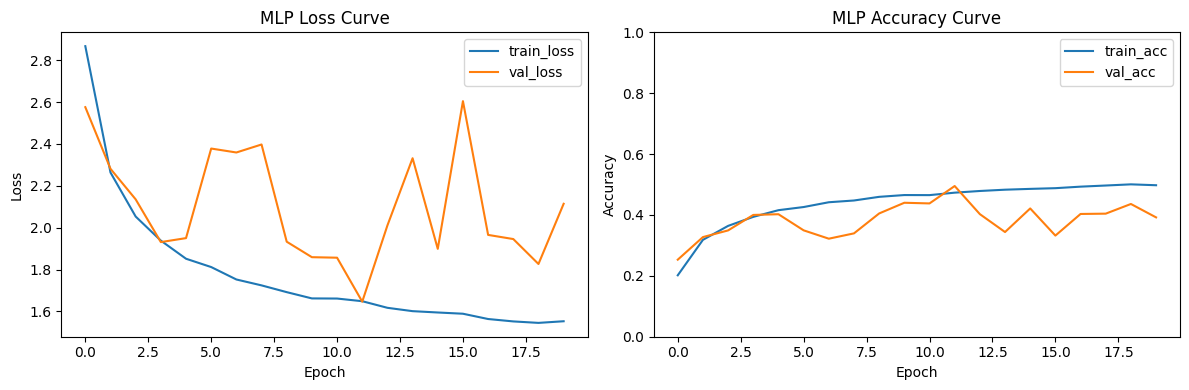

training curves saved to: /content/drive/MyDrive/skeleton_project_outputs/mlp/training_curves_mlp.png


In [12]:
# Plot training curves and save figure
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy Curve")
plt.ylim(0.0, 1.0)
plt.legend()

plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, "training_curves_mlp.png")
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()
print("training curves saved to:", curve_path)


In [13]:
# Cell 11: Load best model and inspect predictions with class names
import pandas as pd
import numpy as np
import torch

ntu60_class_names = [
    "drink water",
    "eat meal",
    "brush teeth",
    "brush hair",
    "drop",
    "pick up",
    "throw",
    "sit down",
    "stand up",
    "clapping",
    "reading",
    "writing",
    "tear up paper",
    "put on jacket",
    "take off jacket",
    "put on a shoe",
    "take off a shoe",
    "put on glasses",
    "take off glasses",
    "put on a hat/cap",
    "take off a hat/cap",
    "cheer up",
    "hand waving",
    "kicking something",
    "reach into pocket",
    "hopping",
    "jump up",
    "phone call",
    "play with phone/tablet",
    "type on a keyboard",
    "point to something",
    "taking a selfie",
    "check time (from watch)",
    "rub two hands",
    "nod head/bow",
    "shake head",
    "wipe face",
    "salute",
    "put palms together",
    "cross hands in front",
    "sneeze/cough",
    "staggering",
    "falling down",
    "headache",
    "chest pain",
    "back pain",
    "neck pain",
    "nausea/vomiting",
    "fan self",
    "punch/slap",
    "kicking",
    "pushing",
    "pat on back",
    "point finger",
    "hugging",
    "giving object",
    "touch pocket",
    "shaking hands",
    "walking towards",
    "walking apart"
]

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

x_batch, y_batch = next(iter(val_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    logits = model(x_batch)
    preds = logits.argmax(dim=1)

true_ids = y_batch.cpu().numpy()
pred_ids = preds.cpu().numpy()

num_show = min(20, len(true_ids))

df_pred = pd.DataFrame({
    "sample_id": np.arange(num_show),
    "true_id": true_ids[:num_show],
    "true_name": [ntu60_class_names[i] for i in true_ids[:num_show]],
    "pred_id": pred_ids[:num_show],
    "pred_name": [ntu60_class_names[i] for i in pred_ids[:num_show]],
    "correct": (true_ids[:num_show] == pred_ids[:num_show])
})

df_pred

,sample_id,true_id,true_name,pred_id,pred_name,correct
0,0,0,drink water,2,brush teeth,False
1,1,1,eat meal,27,phone call,False
2,2,2,brush teeth,36,wipe face,False
3,3,3,brush hair,3,brush hair,True
4,4,4,drop,34,nod head/bow,False
5,5,5,pick up,5,pick up,True
6,6,6,throw,6,throw,True
7,7,7,sit down,7,sit down,True
8,8,8,stand up,8,stand up,True
9,9,9,clapping,38,put palms together,False


In [14]:
# Confusion analysis setup: collect validation predictions once
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = globals().get("ntu60_class_names", [str(i) for i in range(cm.shape[0])])
print("num validation samples:", len(all_labels))
print("confusion matrix shape:", cm.shape)


num validation samples: 16487
confusion matrix shape: (60, 60)


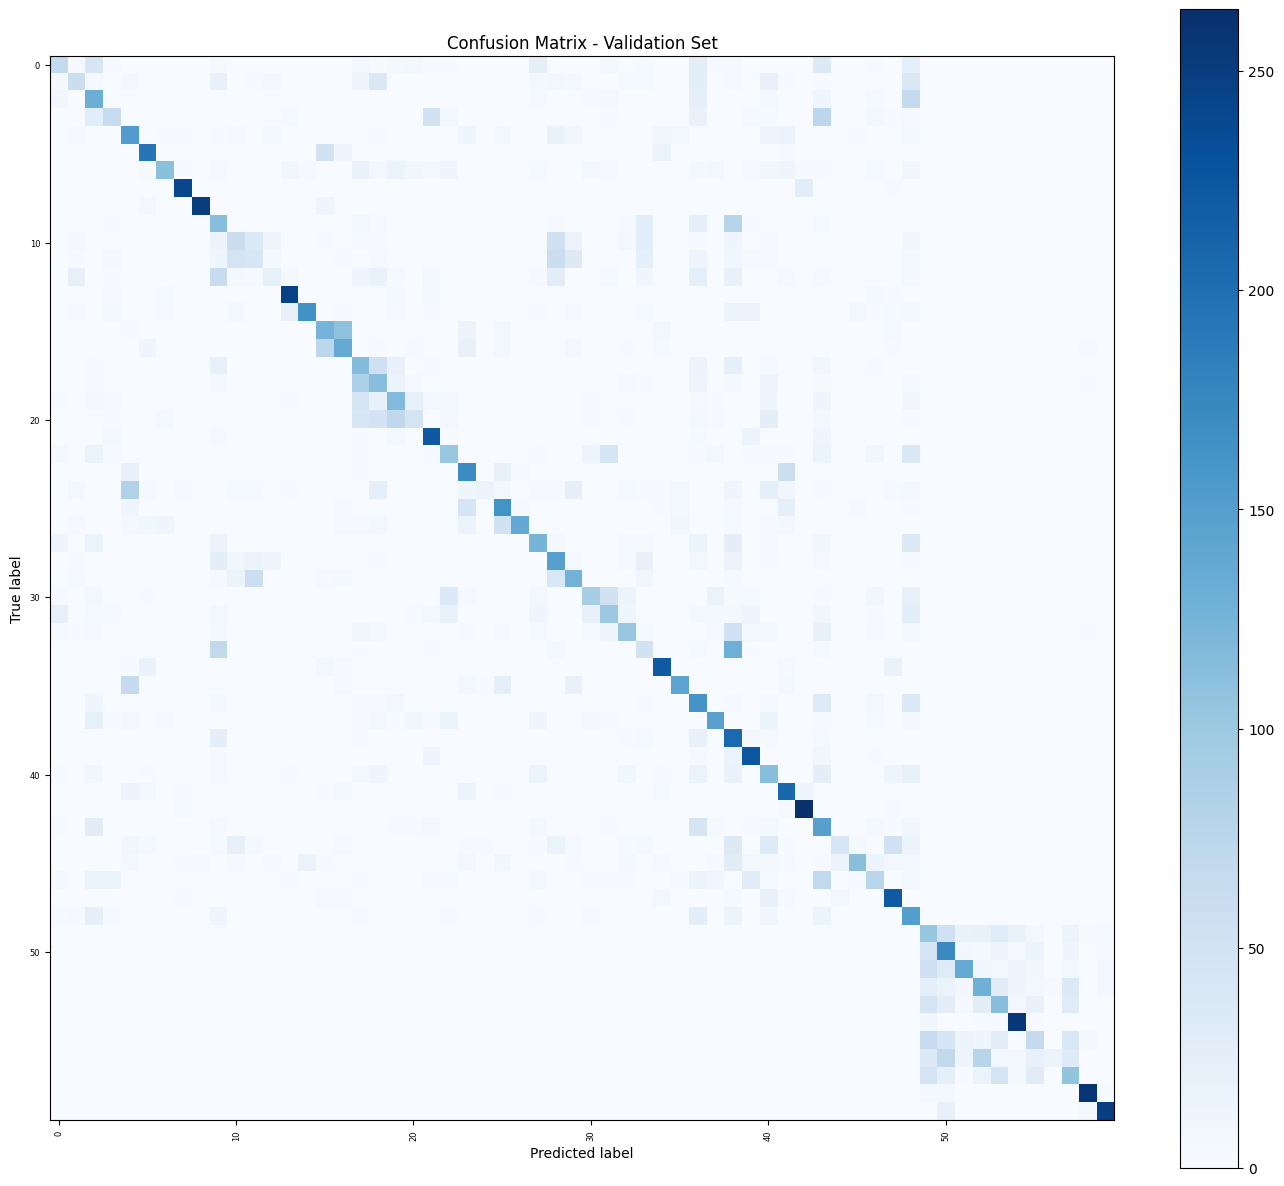

In [15]:
plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()
cm_raw_path = os.path.join(SAVE_DIR, "confusion_matrix_mlp_raw.png")
plt.savefig(cm_raw_path, dpi=300, bbox_inches="tight")
plt.show()


normalized confusion matrix saved to: /content/drive/MyDrive/skeleton_project_outputs/mlp/confusion_matrix_mlp_normalized.png


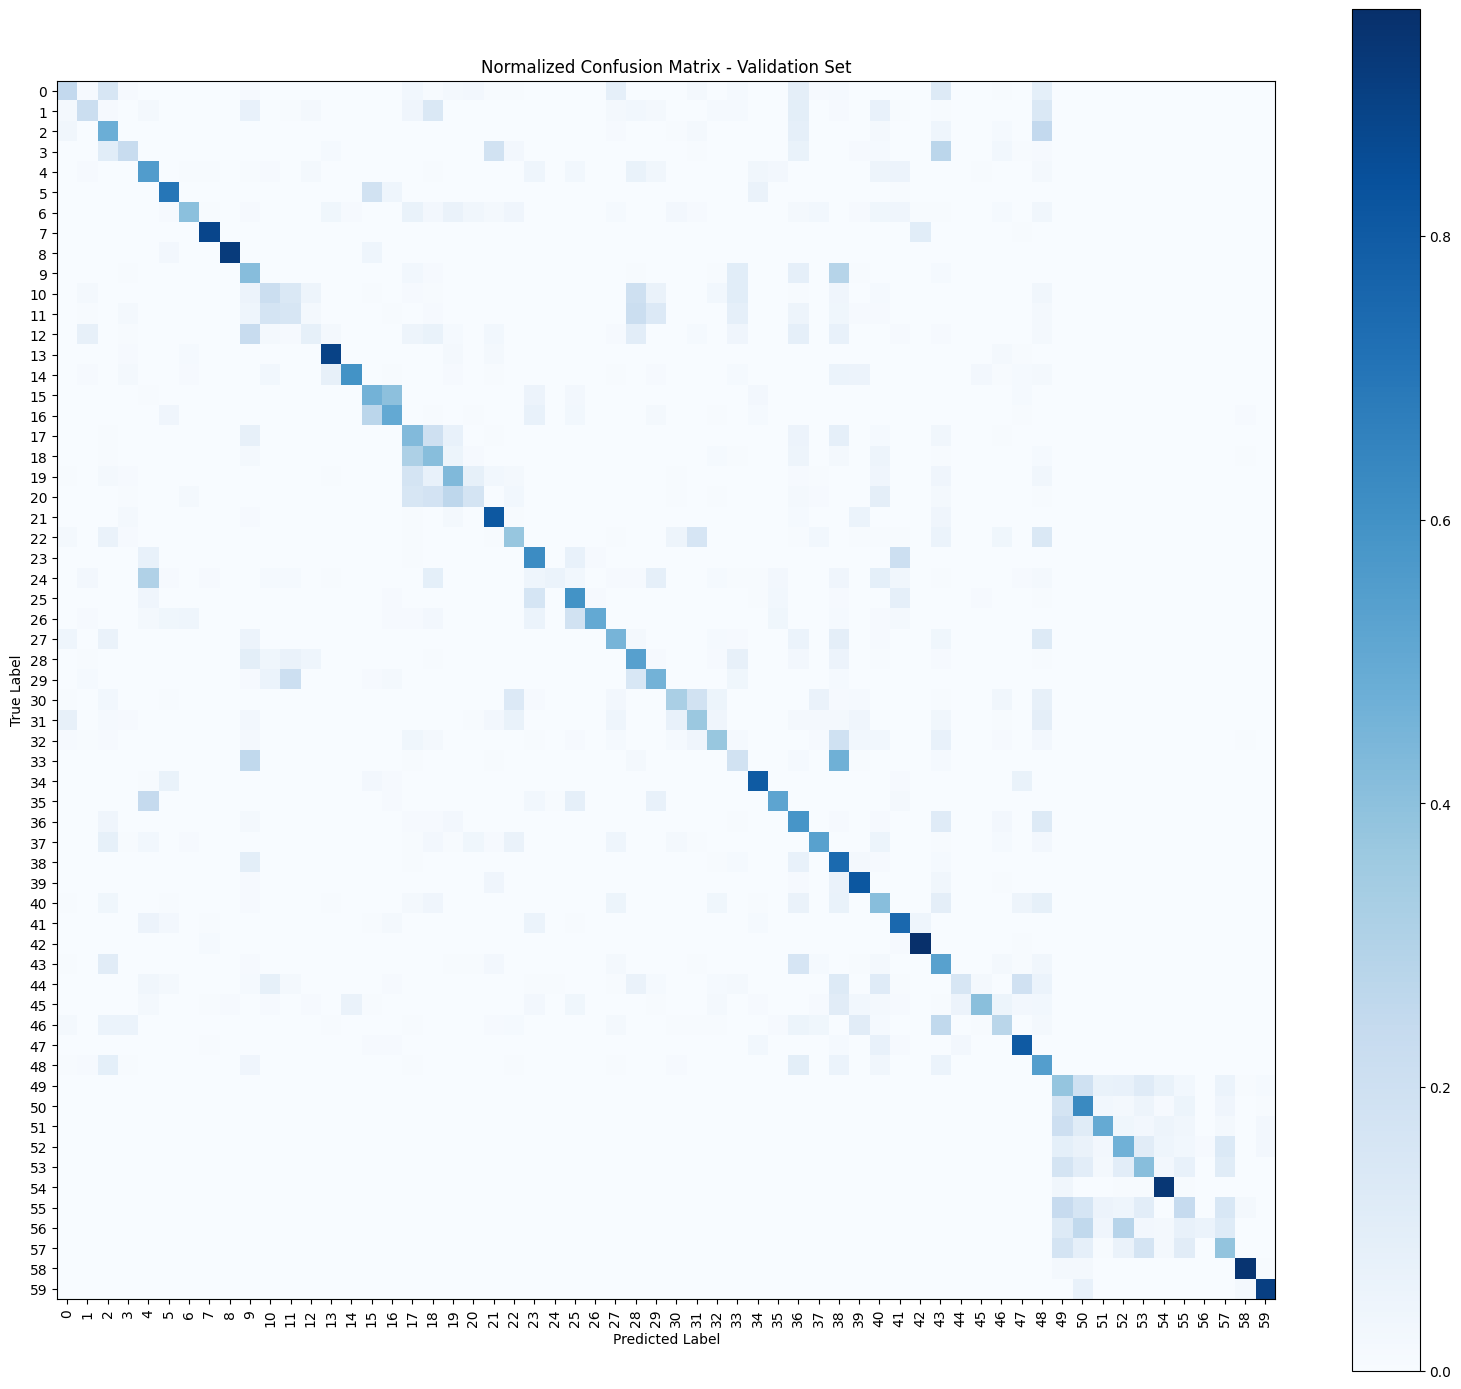

In [16]:
# Save normalized confusion matrix
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")
fig, ax = plt.subplots(figsize=(16, 14))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    colorbar=True,
)

# Hide dense cell labels; the heatmap is easier to read for 60 classes.
for text in disp_norm.text_.ravel():
    text.set_visible(False)

plt.title("Normalized Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
cm_norm_path = os.path.join(SAVE_DIR, "confusion_matrix_mlp_normalized.png")
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")
print("normalized confusion matrix saved to:", cm_norm_path)
plt.show()


In [17]:
# Save top confused pairs by raw count
confusions = []

for true_class in range(cm.shape[0]):
    true_total = cm[true_class].sum()
    for pred_class in range(cm.shape[1]):
        count = int(cm[true_class, pred_class])
        if true_class != pred_class and count > 0:
            rate = count / true_total if true_total > 0 else 0.0
            confusions.append({
                "True class": true_class,
                "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                "Predicted class": pred_class,
                "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                "Count": count,
                "Rate within true class": rate,
            })

confusion_df = pd.DataFrame(confusions)
top_confusions = confusion_df.sort_values(by="Count", ascending=False).head(10)
print(top_confusions)

top_confusions_path = os.path.join(SAVE_DIR, "top_confusions_mlp.csv")
top_confusions.to_csv(top_confusions_path, index=False)
print("top confusions saved to:", top_confusions_path)


     True class           True name  Predicted class      Predicted name  \
609          33       rub two hands               38  put palms together   
270          15       put on a shoe               16     take off a shoe   
314          18    take off glasses               17      put on glasses   
402          24   reach into pocket                4                drop   
934          56        touch pocket               52         pat on back   
165           9            clapping               38  put palms together   
82            3          brush hair               43            headache   
281          16     take off a shoe               15       put on a shoe   
352          20  take off a hat/cap               19    put on a hat/cap   
932          56        touch pocket               50             kicking   

     Count  Rate within true class  
609    130                0.471014  
270    109                0.399267  
314     86                0.313869  
402     84     

In [18]:
# Save top confused pairs by rate within true class
if "confusion_df" not in globals():
    confusions = []
    for true_class in range(cm.shape[0]):
        true_total = cm[true_class].sum()
        for pred_class in range(cm.shape[1]):
            count = int(cm[true_class, pred_class])
            if true_class != pred_class and count > 0:
                rate = count / true_total if true_total > 0 else 0.0
                confusions.append({
                    "True class": true_class,
                    "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                    "Predicted class": pred_class,
                    "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                    "Count": count,
                    "Rate within true class": rate,
                })
    confusion_df = pd.DataFrame(confusions)

top_confusions_by_rate = confusion_df.sort_values(by="Rate within true class", ascending=False).head(10)
print(top_confusions_by_rate)

top_confusions_rate_path = os.path.join(SAVE_DIR, "top_confusions_mlp_by_rate.csv")
top_confusions_by_rate.to_csv(top_confusions_rate_path, index=False)
print("top confusions by rate saved to:", top_confusions_rate_path)


     True class           True name  Predicted class      Predicted name  \
609          33       rub two hands               38  put palms together   
270          15       put on a shoe               16     take off a shoe   
314          18    take off glasses               17      put on glasses   
402          24   reach into pocket                4                drop   
165           9            clapping               38  put palms together   
934          56        touch pocket               52         pat on back   
82            3          brush hair               43            headache   
281          16     take off a shoe               15       put on a shoe   
352          20  take off a hat/cap               19    put on a hat/cap   
932          56        touch pocket               50             kicking   

     Count  Rate within true class  
609    130                0.471014  
270    109                0.399267  
314     86                0.313869  
402     84     

In [19]:
# Save classification report
report = classification_report(all_labels, all_preds, digits=4)
print(report)

report_path = os.path.join(SAVE_DIR, "classification_report_mlp.txt")
with open(report_path, "w") as f:
    f.write(report)
print("classification report saved to:", report_path)


              precision    recall  f1-score   support

           0     0.4658    0.2482    0.3238       274
           1     0.4720    0.2145    0.2950       275
           2     0.3493    0.4799    0.4043       273
           3     0.4961    0.2308    0.3150       273
           4     0.3868    0.5527    0.4551       275
           5     0.7164    0.6982    0.7072       275
           6     0.7450    0.4036    0.5236       275
           7     0.9057    0.8791    0.8922       273
           8     0.9766    0.9158    0.9452       273
           9     0.2522    0.4139    0.3135       273
          10     0.3207    0.2161    0.2582       273
          11     0.2471    0.1544    0.1900       272
          12     0.3014    0.0812    0.1279       271
          13     0.8086    0.8909    0.8478       275
          14     0.8723    0.5942    0.7069       276
          15     0.4355    0.4579    0.4464       273
          16     0.4613    0.5000    0.4799       274
          17     0.2952    